### XGBOOST

In [19]:
import numpy as np  
import matplotlib.pyplot as plt   
import pandas as pd
%matplotlib inline
import seaborn as sns

In [2]:
dataset = pd.read_csv(r"C:\Users\aka90\Desktop\abhi vs code\machine learing\XGBOOT\Churn_Modelling.csv")

In [3]:
dataset

,apst,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,delhi,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,bangalore,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,delhi,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,delhi,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,bangalore,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,delhi,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,delhi,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,delhi,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,mumbai,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
dataset.isnull().sum()

apst               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
dataset.shape

(10000, 14)

In [6]:
x = dataset.iloc[:, 3:-1].values 
y = dataset.iloc[:, -1].values

In [11]:
print(x)

[[619 'delhi' 'Female' ... 1 1 101348.88]
 [608 'bangalore' 'Female' ... 0 1 112542.58]
 [502 'delhi' 'Female' ... 1 0 113931.57]
 ...
 [709 'delhi' 'Female' ... 0 1 42085.58]
 [772 'mumbai' 'Male' ... 1 0 92888.52]
 [792 'delhi' 'Female' ... 1 0 38190.78]]


In [12]:
x

array([[619, 'delhi', 'Female', ..., 1, 1, 101348.88],
       [608, 'bangalore', 'Female', ..., 0, 1, 112542.58],
       [502, 'delhi', 'Female', ..., 1, 0, 113931.57],
       ...,
       [709, 'delhi', 'Female', ..., 0, 1, 42085.58],
       [772, 'mumbai', 'Male', ..., 1, 0, 92888.52],
       [792, 'delhi', 'Female', ..., 1, 0, 38190.78]],
      shape=(10000, 10), dtype=object)

In [15]:
y

array([1, 0, 1, ..., 1, 1, 0], shape=(10000,))

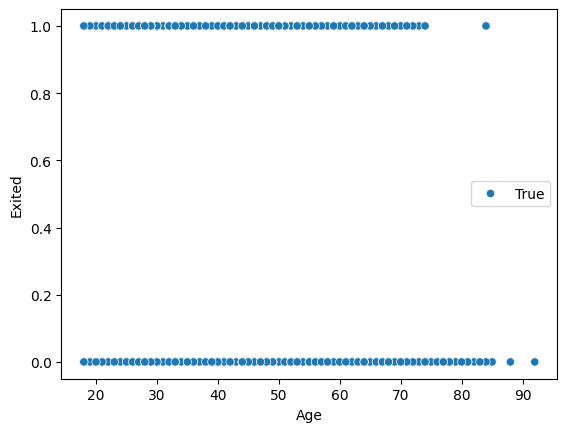

In [20]:
sns.scatterplot(x='Age', y='Exited', data=dataset,hue=True)
plt.show()

In [16]:
dataset.columns

Index(['apst', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

### Encoding categorical data

In [25]:
# Label Encoding the "Gender" columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x[:, 2] = le.fit_transform(x[:, 2])

In [26]:
print(x)

[[619 'delhi' 0 ... 1 1 101348.88]
 [608 'bangalore' 0 ... 0 1 112542.58]
 [502 'delhi' 0 ... 1 0 113931.57]
 ...
 [709 'delhi' 0 ... 0 1 42085.58]
 [772 'mumbai' 1 ... 1 0 92888.52]
 [792 'delhi' 0 ... 1 0 38190.78]]


### One Hot Encoding the "Geography" column

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[1])],remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [28]:
print(x)

[[0.0 1.0 0.0 ... 1 1 101348.88]
 [1.0 0.0 0.0 ... 0 1 112542.58]
 [0.0 1.0 0.0 ... 1 0 113931.57]
 ...
 [0.0 1.0 0.0 ... 0 1 42085.58]
 [0.0 0.0 1.0 ... 1 0 92888.52]
 [0.0 1.0 0.0 ... 1 0 38190.78]]


### Splitting the dataset into the Training set and Test set

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size=0.20,random_state=0)

### Training XGBoost on the Training set

In [32]:
from xgboost import XGBClassifier
classifier = XGBClassifier()
classifier.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Predicting the Test set results

In [33]:
y_pred = classifier.predict(x_test)

## Making the Confusion Matrix

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1496   99]
 [ 192  213]]


In [36]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 85.05 %
Standard Deviation: 1.08 %
